# 第三十章：InstructGPT / RLHF 關鍵組件實作

本 notebook 實作 RLHF (Reinforcement Learning from Human Feedback) 的核心組件，包括：
1. 獎勵模型（Reward Model）
2. 偏好學習損失函數
3. PPO 訓練的關鍵元素
4. KL 散度懲罰

**注意**：完整的 RLHF 訓練請參考 HuggingFace TRL 函式庫。

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# 設定隨機種子
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch 版本: {torch.__version__}")

PyTorch 版本: 2.9.0+cu126


## 1. 獎勵模型（Reward Model）

獎勵模型學習從人類偏好中評估回應品質。

In [27]:
class RewardModel(nn.Module):
    """
    獎勵模型：評估（提示，回應）配對的品質
    
    基於預訓練語言模型，加入獎勵頭
    輸出單一純量分數
    """
    def __init__(self, vocab_size, hidden_size=256, num_layers=4, num_heads=4):
        super().__init__()
        
        # 簡化的 Transformer 編碼器
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.pos_encoding = nn.Embedding(512, hidden_size)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=num_heads,
            dim_feedforward=hidden_size * 4,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
        
        # 獎勵頭：將最後一個 token 的表示映射到純量
        self.reward_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )
        
    def forward(self, input_ids, attention_mask=None):
        """
        Args:
            input_ids: [batch, seq_len] 輸入 token ID
            attention_mask: [batch, seq_len] 注意力遮罩
            
        Returns:
            rewards: [batch] 獎勵分數
        """
        batch_size, seq_len = input_ids.shape
        device = input_ids.device
        
        # Embeddings
        positions = torch.arange(seq_len, device=device).unsqueeze(0)
        x = self.embedding(input_ids) + self.pos_encoding(positions)
        
        # Transformer
        if attention_mask is not None:
            # 轉換為 Transformer 期望的格式
            attention_mask = attention_mask == 0  # True = 遮罩
        x = self.transformer(x, src_key_padding_mask=attention_mask)
        
        # 使用最後一個有效 token 的表示
        if attention_mask is not None:
            # 找到每個序列的最後一個有效位置
            seq_lengths = (~attention_mask).sum(dim=1) - 1
            last_hidden = x[torch.arange(batch_size), seq_lengths]
        else:
            last_hidden = x[:, -1]
        
        # 輸出獎勵
        rewards = self.reward_head(last_hidden).squeeze(-1)
        return rewards

# 測試
reward_model = RewardModel(vocab_size=1000, hidden_size=128, num_layers=2)
input_ids = torch.randint(0, 1000, (4, 32))
rewards = reward_model(input_ids)
print(f"輸入形狀: {input_ids.shape}")
print(f"獎勵形狀: {rewards.shape}")
print(f"獎勵值: {rewards.tolist()}")

輸入形狀: torch.Size([4, 32])
獎勵形狀: torch.Size([4])
獎勵值: [0.3354775905609131, 0.19353023171424866, 0.534809410572052, 0.2813607156276703]


## 2. 偏好學習損失函數

使用 Bradley-Terry 模型學習人類偏好。

In [28]:
def compute_preference_loss(reward_model, chosen_ids, rejected_ids, 
                            chosen_mask=None, rejected_mask=None):
    """
    計算偏好學習損失
    
    Bradley-Terry 模型：
    P(chosen > rejected) = σ(r(chosen) - r(rejected))
    
    損失函數：
    L = -log(σ(r_chosen - r_rejected))
    
    Args:
        reward_model: 獎勵模型
        chosen_ids: [batch, seq_len] 偏好的回應
        rejected_ids: [batch, seq_len] 被拒絕的回應
    """
    # 計算獎勵
    r_chosen = reward_model(chosen_ids, chosen_mask)
    r_rejected = reward_model(rejected_ids, rejected_mask)
    
    # Bradley-Terry 損失
    loss = -F.logsigmoid(r_chosen - r_rejected).mean()
    
    # 計算準確率（用於監控）
    accuracy = (r_chosen > r_rejected).float().mean()
    
    return loss, accuracy, r_chosen.mean(), r_rejected.mean()

# 測試
chosen = torch.randint(0, 1000, (8, 32))
rejected = torch.randint(0, 1000, (8, 32))

loss, acc, r_c, r_r = compute_preference_loss(reward_model, chosen, rejected)
print(f"偏好損失: {loss.item():.4f}")
print(f"準確率: {acc.item():.4f}")
print(f"Chosen 平均獎勵: {r_c.item():.4f}")
print(f"Rejected 平均獎勵: {r_r.item():.4f}")

偏好損失: 0.6378
準確率: 0.5000
Chosen 平均獎勵: 0.2191
Rejected 平均獎勵: 0.0947


## 3. 從排序資料生成配對

人類標註者通常提供排序，需要轉換為配對資料。

In [29]:
def rankings_to_pairs(responses, rankings):
    """
    將排序轉換為配對資料
    
    Args:
        responses: list of responses
        rankings: list of ranks (1 = best)
        
    Returns:
        list of (chosen, rejected) pairs
    """
    pairs = []
    n = len(responses)
    
    for i in range(n):
        for j in range(i + 1, n):
            # 排名較小的是贏家
            if rankings[i] < rankings[j]:
                pairs.append((responses[i], responses[j]))
            elif rankings[j] < rankings[i]:
                pairs.append((responses[j], responses[i]))
            # 排名相同則跳過
    
    return pairs

# 示例
responses = ["Response A", "Response B", "Response C", "Response D"]
rankings = [2, 1, 4, 3]  # B > A > D > C

pairs = rankings_to_pairs(responses, rankings)
print("排序:", dict(zip(responses, rankings)))
print(f"\n生成 {len(pairs)} 個配對:")
for chosen, rejected in pairs:
    print(f"  {chosen} > {rejected}")

排序: {'Response A': 2, 'Response B': 1, 'Response C': 4, 'Response D': 3}

生成 6 個配對:
  Response B > Response A
  Response A > Response C
  Response A > Response D
  Response B > Response C
  Response B > Response D
  Response D > Response C


## 4. KL 散度計算

PPO 訓練中使用 KL 散度防止策略偏離太遠。

In [30]:
def compute_kl_divergence(policy_logprobs, ref_logprobs):
    """
    計算 KL 散度
    
    KL(π || π_ref) = Σ π(a) * log(π(a) / π_ref(a))
                   = Σ π(a) * (log π(a) - log π_ref(a))
    
    在實作中，我們已經有 log probabilities，所以：
    KL ≈ logprob_policy - logprob_ref
    
    Args:
        policy_logprobs: [batch, seq_len] 當前策略的對數機率
        ref_logprobs: [batch, seq_len] 參考策略的對數機率
        
    Returns:
        kl: [batch] 每個樣本的 KL 散度
    """
    kl = policy_logprobs - ref_logprobs
    return kl.sum(dim=-1)  # 對序列求和

# 模擬測試
policy_logprobs = torch.randn(4, 20) * 0.1 - 2  # 模擬對數機率
ref_logprobs = torch.randn(4, 20) * 0.1 - 2

kl = compute_kl_divergence(policy_logprobs, ref_logprobs)
print(f"KL 散度形狀: {kl.shape}")
print(f"KL 散度值: {kl.tolist()}")

KL 散度形狀: torch.Size([4])
KL 散度值: [-0.7398872375488281, 0.2908611297607422, -0.1341625452041626, -0.7229393720626831]


## 5. PPO 目標函數

PPO 使用剪裁目標函數來穩定訓練。

In [31]:
def compute_ppo_loss(
    old_logprobs,
    new_logprobs,
    advantages,
    clip_range=0.2
):
    """
    計算 PPO 剪裁目標函數
    
    L_CLIP = E[min(r_t * A_t, clip(r_t, 1-ε, 1+ε) * A_t)]
    
    其中 r_t = π_new(a|s) / π_old(a|s)
    
    Args:
        old_logprobs: [batch, seq_len] 舊策略的對數機率
        new_logprobs: [batch, seq_len] 新策略的對數機率
        advantages: [batch] 優勢函數值
        clip_range: 剪裁範圍
        
    Returns:
        loss: PPO 損失
    """
    # 計算機率比
    # r_t = exp(log π_new - log π_old)
    ratio = torch.exp(new_logprobs.sum(dim=-1) - old_logprobs.sum(dim=-1))
    
    # 剪裁的機率比
    clipped_ratio = torch.clamp(ratio, 1 - clip_range, 1 + clip_range)
    
    # PPO 損失（取較小者以保守更新）
    loss1 = ratio * advantages
    loss2 = clipped_ratio * advantages
    loss = -torch.min(loss1, loss2).mean()
    
    # 計算剪裁比例（用於監控）
    clip_fraction = ((ratio - 1).abs() > clip_range).float().mean()
    
    return loss, clip_fraction

# 測試
old_logprobs = torch.randn(8, 20) * 0.1 - 2
new_logprobs = old_logprobs + torch.randn(8, 20) * 0.1  # 小幅變化
advantages = torch.randn(8)

loss, clip_frac = compute_ppo_loss(old_logprobs, new_logprobs, advantages)
print(f"PPO 損失: {loss.item():.4f}")
print(f"剪裁比例: {clip_frac.item():.4f}")

PPO 損失: 0.1173
剪裁比例: 0.5000


## 6. 完整的 RLHF 獎勵計算

In [32]:
def compute_rlhf_reward(
    reward_model,
    policy_logprobs,
    ref_logprobs,
    response_ids,
    kl_coef=0.1
):
    """
    計算 RLHF 的最終獎勵
    
    最終獎勵 = RM獎勵 - β × KL(π || π_ref)
    
    Args:
        reward_model: 獎勵模型
        policy_logprobs: 當前策略的對數機率
        ref_logprobs: 參考策略的對數機率
        response_ids: 生成的回應 token IDs
        kl_coef: KL 懲罰係數
        
    Returns:
        total_reward: 最終獎勵
        rm_reward: RM 獎勵
        kl_penalty: KL 懲罰
    """
    # RM 獎勵
    rm_reward = reward_model(response_ids)
    
    # KL 懲罰
    kl = compute_kl_divergence(policy_logprobs, ref_logprobs)
    kl_penalty = kl_coef * kl
    
    # 最終獎勵
    total_reward = rm_reward - kl_penalty
    
    return total_reward, rm_reward, kl_penalty

# 測試
response_ids = torch.randint(0, 1000, (4, 32))
policy_logprobs = torch.randn(4, 32) * 0.1 - 2
ref_logprobs = torch.randn(4, 32) * 0.1 - 2

total, rm, kl_pen = compute_rlhf_reward(
    reward_model, policy_logprobs, ref_logprobs, response_ids
)
print(f"RM 獎勵: {rm.mean().item():.4f}")
print(f"KL 懲罰: {kl_pen.mean().item():.4f}")
print(f"總獎勵: {total.mean().item():.4f}")

RM 獎勵: 0.2872
KL 懲罰: 0.0408
總獎勵: 0.2465


## 7. 訓練獎勵模型

In [33]:
def train_reward_model(
    reward_model,
    train_data,  # list of (chosen, rejected) pairs
    num_epochs=3,
    lr=1e-4,
    batch_size=8
):
    """
    訓練獎勵模型
    """
    optimizer = torch.optim.Adam(reward_model.parameters(), lr=lr)
    
    history = {'loss': [], 'accuracy': []}
    
    for epoch in range(num_epochs):
        epoch_loss = 0
        epoch_acc = 0
        num_batches = 0
        
        # 隨機打亂資料
        indices = torch.randperm(len(train_data))
        
        for i in range(0, len(train_data), batch_size):
            batch_indices = indices[i:i+batch_size]
            
            # 收集批次資料
            chosen_batch = torch.stack([train_data[j][0] for j in batch_indices])
            rejected_batch = torch.stack([train_data[j][1] for j in batch_indices])
            
            # 計算損失
            loss, acc, _, _ = compute_preference_loss(
                reward_model, chosen_batch, rejected_batch
            )
            
            # 反向傳播
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            epoch_acc += acc.item()
            num_batches += 1
        
        avg_loss = epoch_loss / num_batches
        avg_acc = epoch_acc / num_batches
        
        history['loss'].append(avg_loss)
        history['accuracy'].append(avg_acc)
        
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}, Accuracy: {avg_acc:.4f}")
    
    return history

# 創建模擬訓練資料
num_samples = 100
train_data = []
for _ in range(num_samples):
    # 模擬：chosen 的 ID 較小（假設較小的 ID 代表較好的回應）
    chosen = torch.randint(0, 500, (32,))
    rejected = torch.randint(500, 1000, (32,))
    train_data.append((chosen, rejected))

# 訓練
print("訓練獎勵模型...")
reward_model = RewardModel(vocab_size=1000, hidden_size=128, num_layers=2)
history = train_reward_model(reward_model, train_data, num_epochs=5)

訓練獎勵模型...
Epoch 1/5 - Loss: 0.6982, Accuracy: 0.4904
Epoch 2/5 - Loss: 0.6510, Accuracy: 0.6635
Epoch 3/5 - Loss: 0.6250, Accuracy: 0.7885
Epoch 4/5 - Loss: 0.5792, Accuracy: 0.8750
Epoch 5/5 - Loss: 0.5354, Accuracy: 0.9423


## 8. 視覺化訓練過程

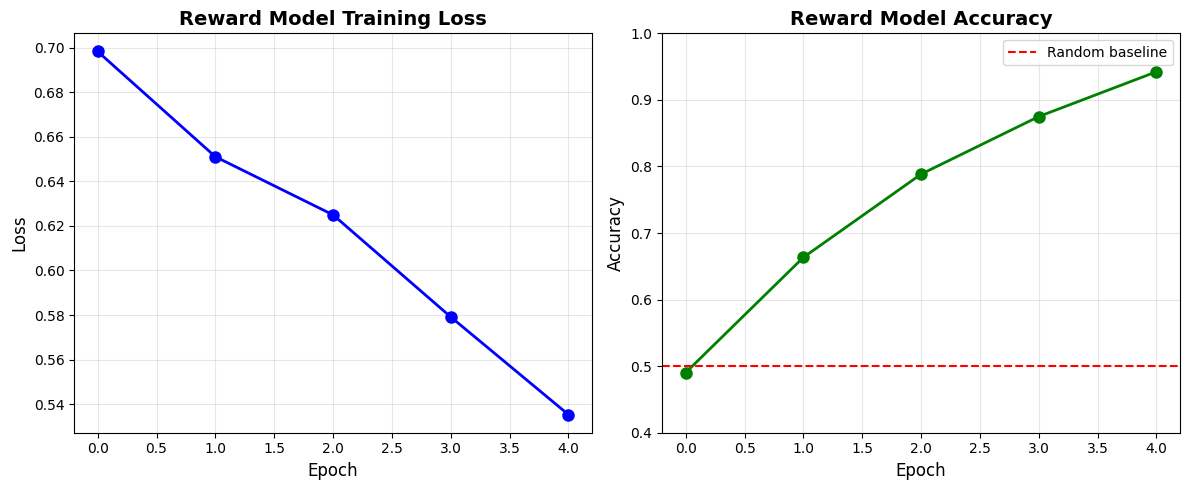


圖片已儲存為 rm_training.png


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 損失曲線
ax1 = axes[0]
ax1.plot(history['loss'], 'b-o', linewidth=2, markersize=8)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Reward Model Training Loss', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 準確率曲線
ax2 = axes[1]
ax2.plot(history['accuracy'], 'g-o', linewidth=2, markersize=8)
ax2.axhline(y=0.5, color='r', linestyle='--', label='Random baseline')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Reward Model Accuracy', fontsize=14, fontweight='bold')
ax2.set_ylim(0.4, 1.0)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rm_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n圖片已儲存為 rm_training.png")

## 9. 模擬 PPO 訓練步驟

In [35]:
class SimplePolicy(nn.Module):
    """簡化的策略模型（用於示範）"""
    def __init__(self, vocab_size, hidden_size=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.rnn = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, vocab_size)
        
    def forward(self, input_ids):
        x = self.embedding(input_ids)
        x, _ = self.rnn(x)
        logits = self.output(x)
        return logits
    
    def compute_logprobs(self, prompt_ids, response_ids):
        """
        計算生成 response 的對數機率
        
        將 prompt 和 response 串接後輸入模型，
        取 response 位置對應的 logits 來計算機率
        """
        # 串接 prompt 和 response
        full_ids = torch.cat([prompt_ids, response_ids], dim=1)
        
        # 取得完整序列的 logits
        logits = self.forward(full_ids)
        logprobs = F.log_softmax(logits, dim=-1)
        
        # 取 prompt 最後一個位置到倒數第二個位置的 logits
        # 這些位置預測的是 response tokens
        prompt_len = prompt_ids.shape[1]
        response_len = response_ids.shape[1]
        
        # logits[prompt_len-1] 預測 response[0]
        # logits[prompt_len] 預測 response[1]
        # ...以此類推
        response_logprobs = logprobs[:, prompt_len-1:-1, :]  # [B, response_len, vocab]
        
        # 取出實際生成 token 的對數機率
        selected_logprobs = response_logprobs.gather(
            2, response_ids.unsqueeze(-1)
        ).squeeze(-1)  # [B, response_len]
        
        return selected_logprobs


def ppo_training_step(
    policy,
    ref_policy,
    reward_model,
    prompt_ids,
    response_ids,
    optimizer,
    kl_coef=0.1,
    clip_range=0.2
):
    """
    PPO 訓練步驟
    """
    # 計算當前和參考策略的對數機率
    with torch.no_grad():
        old_logprobs = policy.compute_logprobs(prompt_ids, response_ids).detach()
        ref_logprobs = ref_policy.compute_logprobs(prompt_ids, response_ids)
    
    # 計算獎勵
    with torch.no_grad():
        full_ids = torch.cat([prompt_ids, response_ids], dim=1)
        rewards, rm_reward, kl_pen = compute_rlhf_reward(
            reward_model, old_logprobs, ref_logprobs, full_ids, kl_coef
        )
    
    # 計算新的對數機率
    new_logprobs = policy.compute_logprobs(prompt_ids, response_ids)
    
    # PPO 損失
    ppo_loss, clip_frac = compute_ppo_loss(
        old_logprobs, new_logprobs, rewards, clip_range
    )
    
    # 優化
    optimizer.zero_grad()
    ppo_loss.backward()
    optimizer.step()
    
    return {
        'ppo_loss': ppo_loss.item(),
        'rm_reward': rm_reward.mean().item(),
        'kl_penalty': kl_pen.mean().item(),
        'total_reward': rewards.mean().item(),
        'clip_fraction': clip_frac.item()
    }

# 測試
policy = SimplePolicy(vocab_size=1000)
ref_policy = SimplePolicy(vocab_size=1000)
ref_policy.load_state_dict(policy.state_dict())  # 複製參數

optimizer = torch.optim.Adam(policy.parameters(), lr=1e-4)

prompt_ids = torch.randint(0, 1000, (4, 16))
response_ids = torch.randint(0, 1000, (4, 32))

metrics = ppo_training_step(
    policy, ref_policy, reward_model,
    prompt_ids, response_ids, optimizer
)

print("PPO 訓練步驟指標:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

PPO 訓練步驟指標:
  ppo_loss: -0.1053
  rm_reward: 0.1053
  kl_penalty: 0.0000
  total_reward: 0.1053
  clip_fraction: 0.0000


## 10. 視覺化：RLHF 各組件的作用

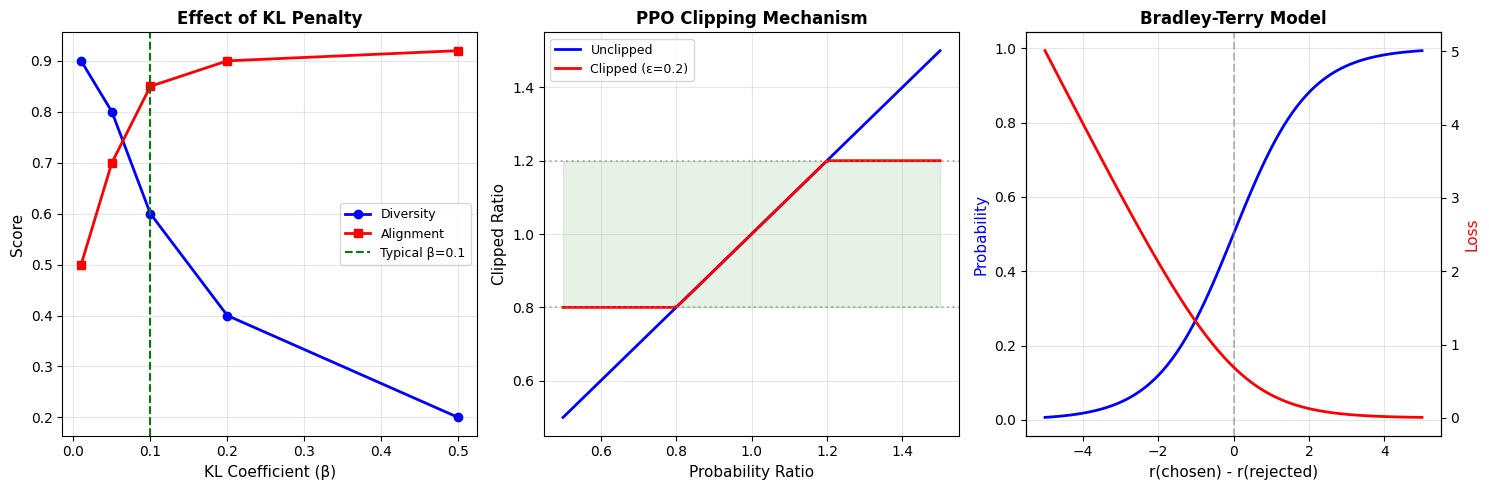


圖片已儲存為 rlhf_components.png


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 圖 1：KL 懲罰係數的影響
ax1 = axes[0]
kl_coefs = [0.01, 0.05, 0.1, 0.2, 0.5]
diversity_proxy = [0.9, 0.8, 0.6, 0.4, 0.2]  # 模擬
alignment_proxy = [0.5, 0.7, 0.85, 0.9, 0.92]  # 模擬

ax1.plot(kl_coefs, diversity_proxy, 'b-o', linewidth=2, label='Diversity')
ax1.plot(kl_coefs, alignment_proxy, 'r-s', linewidth=2, label='Alignment')
ax1.axvline(x=0.1, color='green', linestyle='--', label='Typical β=0.1')
ax1.set_xlabel('KL Coefficient (β)', fontsize=11)
ax1.set_ylabel('Score', fontsize=11)
ax1.set_title('Effect of KL Penalty', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# 圖 2：PPO 剪裁的效果
ax2 = axes[1]
ratio = np.linspace(0.5, 1.5, 100)
clip_range = 0.2
clipped = np.clip(ratio, 1 - clip_range, 1 + clip_range)

ax2.plot(ratio, ratio, 'b-', linewidth=2, label='Unclipped')
ax2.plot(ratio, clipped, 'r-', linewidth=2, label='Clipped (ε=0.2)')
ax2.axhline(y=1-clip_range, color='gray', linestyle=':', alpha=0.5)
ax2.axhline(y=1+clip_range, color='gray', linestyle=':', alpha=0.5)
ax2.fill_between([0.5, 1.5], 1-clip_range, 1+clip_range, alpha=0.1, color='green')
ax2.set_xlabel('Probability Ratio', fontsize=11)
ax2.set_ylabel('Clipped Ratio', fontsize=11)
ax2.set_title('PPO Clipping Mechanism', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# 圖 3：Bradley-Terry 損失函數
ax3 = axes[2]
diff = np.linspace(-5, 5, 100)
prob = 1 / (1 + np.exp(-diff))
loss = -np.log(prob + 1e-10)

ax3.plot(diff, prob, 'b-', linewidth=2, label='P(chosen > rejected)')
ax3_twin = ax3.twinx()
ax3_twin.plot(diff, loss, 'r-', linewidth=2, label='Loss')

ax3.set_xlabel('r(chosen) - r(rejected)', fontsize=11)
ax3.set_ylabel('Probability', fontsize=11, color='blue')
ax3_twin.set_ylabel('Loss', fontsize=11, color='red')
ax3.set_title('Bradley-Terry Model', fontsize=12, fontweight='bold')
ax3.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rlhf_components.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n圖片已儲存為 rlhf_components.png")

## 11. 總結

本 notebook 實作了 RLHF (InstructGPT) 的核心組件：

1. **獎勵模型**：
   - 基於 Transformer 編碼器
   - 輸出單一純量獎勵
   - 使用 Bradley-Terry 模型訓練

2. **偏好學習**：
   - 從排序資料生成配對
   - 計算 pairwise ranking loss
   - 學習人類偏好

3. **PPO 訓練**：
   - 剪裁目標函數保證穩定性
   - KL 散度懲罰防止偏離
   - 結合 RM 獎勵和 KL 懲罰

### 實際使用建議

對於實際的 RLHF 訓練，建議使用：
- **TRL (Transformers Reinforcement Learning)**：HuggingFace 官方函式庫
- **DeepSpeed-Chat**：高效的分佈式訓練
- **trlx**：功能完整的 RLHF 框架

### RLHF vs DPO

近期 DPO (Direct Preference Optimization) 提供了更簡單的替代方案：
- 不需要訓練獎勵模型
- 直接從偏好資料優化策略
- 訓練更穩定

但 RLHF 仍然是理解現代對齊技術的基礎。